In [2]:
from google.colab import drive
drive.mount('/content/drive',)

Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [
    CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR,
    MODEL_DIR, GRAPH_DIR, REPORT_DIR,
    PRED_DIR, EXPLAIN_DIR, UNCERTAIN_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [4]:
!pip install -q moviepy librosa soundfile opencv-python transformers sentence-transformers openai-whisper
!pip install -q spafe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 50.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 8.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import json
import os

metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

df = pd.DataFrame(metadata).T.reset_index()
df = df.rename(columns={"index": "filename"})

df["label"] = df["label"].str.upper()

# REAL = 1, FAKE = 0
df["label_num"] = df["label"].map({
    "REAL": 1,
    "FAKE": 0
})

df["video_path"] = df["filename"].apply(lambda x: os.path.join(RAW_DIR, x))

df = df[df["video_path"].apply(os.path.exists)]

print(df.head())
print(df["label"].value_counts())

         filename label  split        original  label_num  \
0  owxbbpjpch.mp4  FAKE  train  wynotylpnm.mp4          0   
1  vpmyeepbep.mp4  REAL  train             NaN          1   
2  fzvpbrzssi.mp4  REAL  train             NaN          1   
3  htorvhbcae.mp4  FAKE  train  wclvkepakb.mp4          0   
4  fckxaqjbxk.mp4  FAKE  train  vpmyeepbep.mp4          0   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r...  
label
FAKE    1248
REAL      86
Name: count, dtype: int64


In [6]:
real_df = df[df["label"] == "REAL"]
fake_df = df[df["label"] == "FAKE"]

min_count = min(len(real_df), len(fake_df))

balanced_df = pd.concat([
    real_df.sample(min_count, random_state=42),
    fake_df.sample(min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

balanced_csv_path = os.path.join(CSV_DIR, "balanced_metadata.csv")
balanced_df.to_csv(balanced_csv_path, index=False)

print("Balanced data saved:", balanced_csv_path)
print(balanced_df["label"].value_counts())

Balanced data saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/balanced_metadata.csv
label
REAL    86
FAKE    86
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df["label_num"]
)

train_csv = os.path.join(CSV_DIR, "train.csv")
test_csv = os.path.join(CSV_DIR, "test.csv")

train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Train:", train_df["label"].value_counts())
print("Test:", test_df["label"].value_counts())

Train: label
REAL    69
FAKE    68
Name: count, dtype: int64
Test: label
FAKE    18
REAL    17
Name: count, dtype: int64


In [8]:
import cv2
from tqdm import tqdm

def extract_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()


for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    save_dir = os.path.join(FRAMES_DIR, video_name)
    extract_frames(row["video_path"], save_dir)

100%|██████████| 172/172 [19:25<00:00,  6.78s/it]


In [ ]:
import shutil

VISUAL_DATASET_DIR = os.path.join(PROCESSED_DIR, "visual_dataset")

for split_name, split_df in [("train", train_df), ("test", test_df)]:
    for label in ["REAL", "FAKE"]:
        os.makedirs(os.path.join(VISUAL_DATASET_DIR, split_name, label), exist_ok=True)

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        video_name = row["filename"].replace(".mp4", "")
        src_dir = os.path.join(FRAMES_DIR, video_name)
        label = row["label"]

        if os.path.exists(src_dir):
            for frame_file in os.listdir(src_dir):
                src = os.path.join(src_dir, frame_file)
                dst = os.path.join(
                    VISUAL_DATASET_DIR,
                    split_name,
                    label,
                    video_name + "_" + frame_file
                )
                shutil.copy(src, dst)

100%|██████████| 35/35 [08:58<00:00, 15.38s/it]


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5

train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(VISUAL_DATASET_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    os.path.join(VISUAL_DATASET_DIR, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(train_data.class_indices)

Found 2055 images belonging to 2 classes.
Found 525 images belonging to 2 classes.
{'FAKE': 0, 'REAL': 1}


In [ ]:
def build_visual_model(base_model_name):
    if base_model_name == "mobilenet":
        base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_model_name == "resnet":
        base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_model_name == "efficientnet":
        base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))

    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # sigmoid gives REAL probability because REAL = 1
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
visual_models = {}

for model_name in ["mobilenet", "resnet", "efficientnet"]:
    print("Training:", model_name)

    model = build_visual_model(model_name)

    history = model.fit(
        train_data,
        validation_data=test_data,
        epochs=EPOCHS
    )

    save_path = os.path.join(MODEL_DIR, f"{model_name}_visual_model.keras")
    model.save(save_path)

    visual_models[model_name] = {"model": model, "history": history}

    print("Saved:", save_path)

Training: mobilenet
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 52s 270ms/step - accuracy: 0.6209 - loss: 0.7070 - val_accuracy: 0.6762 - val_loss: 0.6222
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.6667 - loss: 0.6157 - val_accuracy: 0.6952 - val_loss: 0.6507
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.6691 - loss: 0.6084 - val_accuracy: 0.6381 - val_loss: 0.6903
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.6667 - loss: 0.5944 - val_accuracy: 0.6362 - val_loss: 0.6698
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.6725 - loss: 0.5916 - val_accuracy: 0.5924 - val_loss: 0.6841
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/mobilenet_visual_model.keras
Training: resnet
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 31s 155ms/step - accuracy: 0.5139 - loss: 0.7170 - val_accuracy: 0.4857 - val_loss: 0.

In [ ]:
from moviepy.editor import VideoFileClip

def extract_audio(video_path, audio_path):
    try:
        clip = VideoFileClip(video_path)
        if clip.audio is not None:
            clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
        clip.close()
    except Exception as e:
        print("Audio error:", video_path, e)


for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    if not os.path.exists(audio_path):
        extract_audio(row["video_path"], audio_path)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

100%|██████████| 172/172 [00:00<00:00, 174.08it/s]


In [ ]:
import librosa
import numpy as np
from spafe.features.rplp import plp

def extract_mfcc(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    return np.mean(mfcc, axis=1)

def extract_mel(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel)
    return np.mean(mel_db, axis=1)

def extract_plp(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    # Removed 'n_ceps' as it seems to be an unsupported argument in this environment
    features = plp(y, fs=sr)
    return np.mean(features, axis=0)

In [ ]:
audio_rows = []

for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    if os.path.exists(audio_path):
        try:
            mfcc_feat = extract_mfcc(audio_path)
            mel_feat = extract_mel(audio_path)
            plp_feat = extract_plp(audio_path)

            audio_rows.append({
                "filename": row["filename"],
                "label_num": row["label_num"],
                "mfcc": mfcc_feat,
                "mel": mel_feat,
                "plp": plp_feat
            })

        except Exception as e:
            print("Feature error:", row["filename"], e)

audio_df = pd.DataFrame(audio_rows)
print(audio_df.head())

100%|██████████| 172/172 [02:06<00:00,  1.36it/s]

         filename  label_num  \
0  fufcmupzen.mp4          1   
1  muhgixhdmd.mp4          0   
2  haxnhfvqvs.mp4          0   
3  rmuxlgsedw.mp4          1   
4  yeouperxzc.mp4          0   

                                                mfcc  \
0  [-394.5546, 75.85335, 9.717397, 25.677855, -7....   
1  [-442.6298, 92.479454, 34.893433, 34.29909, 10...   
2  [-459.5948, 80.61326, 2.0073216, 18.493374, -1...   
3  [-463.23273, 77.284584, 16.221611, 29.732971, ...   
4  [-450.37085, 70.31432, 19.556288, 24.422428, -...   

                                                 mel  \
0  [-21.002556, -18.81882, -20.363008, -20.852863...   
1  [-20.225826, -18.281742, -13.825868, -13.95782...   
2  [-38.79412, -33.175655, -20.590044, -22.150543...   
3  [-33.316242, -28.26538, -20.293837, -22.724045...   
4  [-31.159323, -28.43566, -18.371407, -19.483698...   

                                                 plp  
0  [-86.4593190122961, -1.0075104481415713, -0.50...  
1  [-83.66402465952855,

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import joblib

def train_audio_model(feature_name, model, save_name):
    X = np.vstack(audio_df[feature_name].values)
    y = audio_df["label_num"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(save_name, "accuracy:", acc)

    path = os.path.join(MODEL_DIR, save_name)
    joblib.dump(model, path)

    return model

mfcc_model = train_audio_model(
    "mfcc",
    RandomForestClassifier(n_estimators=100, random_state=42),
    "mfcc_audio_model.pkl"
)

mel_model = train_audio_model(
    "mel",
    LogisticRegression(max_iter=1000),
    "mel_audio_model.pkl"
)

plp_model = train_audio_model(
    "plp",
    SVC(probability=True),
    "plp_audio_model.pkl"
)

mfcc_audio_model.pkl accuracy: 0.5142857142857142


STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



mel_audio_model.pkl accuracy: 0.4857142857142857
plp_audio_model.pkl accuracy: 0.4857142857142857


In [ ]:
import whisper

whisper_model = whisper.load_model("base")

def transcribe_audio(audio_path):
    try:
        result = whisper_model.transcribe(audio_path)
        return result["text"]
    except Exception as e:
        print("Transcription error:", e)
        return ""

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 162MiB/s]


In [ ]:
text_rows = []

for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    transcript_path = os.path.join(TEXT_DIR, video_name + ".txt")

    if os.path.exists(transcript_path):
        with open(transcript_path, "r", encoding="utf-8") as f:
            transcript = f.read()
    else:
        transcript = transcribe_audio(audio_path)

        with open(transcript_path, "w", encoding="utf-8") as f:
            f.write(transcript)

    text_rows.append({
        "filename": row["filename"],
        "label_num": row["label_num"],
        "transcript": transcript
    })

text_df = pd.DataFrame(text_rows)
text_df.head()

100%|██████████| 172/172 [00:31<00:00,  5.49it/s]


,filename,label_num,transcript
0,fufcmupzen.mp4,1,Typically junk food is preparing our brains t...
1,muhgixhdmd.mp4,0,"Why do we need art? Well, we need art for so ..."
2,haxnhfvqvs.mp4,0,of times they will not get the proper attenti...
3,rmuxlgsedw.mp4,1,So I guess the point of that being we would p...
4,yeouperxzc.mp4,0,of what is important to us. So I do think tha...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
import joblib

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    text_df["transcript"],
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

tfidf_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

tfidf_model.fit(X_train, y_train)

print("TF-IDF accuracy:", tfidf_model.score(X_test, y_test))

joblib.dump(tfidf_model, os.path.join(MODEL_DIR, "tfidf_text_model.pkl"))

TF-IDF accuracy: 0.45714285714285713


['/content/drive/MyDrive/Deepfake_Project/data/outputs/models/tfidf_text_model.pkl']

In [ ]:
bert_embedder = SentenceTransformer("bert-base-nli-mean-tokens")

bert_embeddings = bert_embedder.encode(
    text_df["transcript"].tolist(),
    show_progress_bar=True
)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings,
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

bert_clf = LogisticRegression(max_iter=1000)
bert_clf.fit(X_train, y_train)

print("BERT accuracy:", bert_clf.score(X_test, y_test))

joblib.dump(bert_clf, os.path.join(MODEL_DIR, "bert_text_model.pkl"))

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

BERT accuracy: 0.45714285714285713


['/content/drive/MyDrive/Deepfake_Project/data/outputs/models/bert_text_model.pkl']

In [ ]:
roberta_embedder = SentenceTransformer("sentence-transformers/all-roberta-large-v1")

roberta_embeddings = roberta_embedder.encode(
    text_df["transcript"].tolist(),
    show_progress_bar=True
)

X_train, X_test, y_train, y_test = train_test_split(
    roberta_embeddings,
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

roberta_clf = RandomForestClassifier(n_estimators=100, random_state=42)
roberta_clf.fit(X_train, y_train)

print("RoBERTa accuracy:", roberta_clf.score(X_test, y_test))

joblib.dump(roberta_clf, os.path.join(MODEL_DIR, "roberta_text_model.pkl"))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

RoBERTa accuracy: 0.5714285714285714


['/content/drive/MyDrive/Deepfake_Project/data/outputs/models/roberta_text_model.pkl']

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_visual_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    frame_dir = os.path.join(FRAMES_DIR, video_name)

    frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224,224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        model_scores = []

        for model_name, model in visual_models.items():
            score = model.predict(img_arr, verbose=0)[0][0]
            model_scores.append(score)

        frame_scores.append(np.mean(model_scores))

    visual_score = np.mean(frame_scores)

    return float(visual_score)

In [ ]:
def predict_audio_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)
    plp_feat = extract_plp(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]
    plp_score = plp_model.predict_proba(plp_feat)[0][1]

    audio_score = np.mean([
        mfcc_score,
        mel_score,
        plp_score
    ])

    return float(audio_score)

In [ ]:
def predict_text_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    transcript_path = os.path.join(TEXT_DIR, video_name + ".txt")

    with open(transcript_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    text_score = np.mean([
        tfidf_score,
        bert_score,
        roberta_score
    ])

    return float(text_score)

In [ ]:
def classify_final_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
def generate_verdict_explanation(visual_score, audio_score, text_score, final_score, predicted_label):
    explanation = (
        f"The visual score is {visual_score:.4f}, audio score is {audio_score:.4f}, "
        f"and text score is {text_score:.4f}. The final multimodal average score is "
        f"{final_score:.4f}. Since the score is classified as {predicted_label}, "
    )

    if predicted_label == "REAL":
        explanation += "the video is predicted as real because the final score is closer to the REAL class."
    elif predicted_label == "FAKE":
        explanation += "the video is predicted as fake because the final score is closer to the FAKE class."
    else:
        explanation += "the video is marked uncertain because the score lies in the middle confidence range."

    return explanation

In [ ]:
final_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_score(filename)
        audio_score = predict_audio_score(filename)
        text_score = predict_text_score(filename)

        final_score = np.mean([
            visual_score,
            audio_score,
            text_score
        ])

        predicted_label = classify_final_score(final_score)

        verdict = "Correct" if predicted_label == true_label else "Incorrect"

        if predicted_label == "UNCERTAIN":
            verdict = "Needs Human Review"

        explanation = generate_verdict_explanation(
            visual_score,
            audio_score,
            text_score,
            final_score,
            predicted_label
        )

        final_results.append({
            "filename": filename,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "final_score": final_score,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

final_df = pd.DataFrame(final_results)

final_csv_path = os.path.join(PRED_DIR, "final_multimodal_predictions.csv")
final_df.to_csv(final_csv_path, index=False)

print("Saved:", final_csv_path)
final_df.head()

100%|██████████| 35/35 [02:22<00:00,  4.08s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/final_multimodal_predictions.csv


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.488450,0.295153,0.248400,0.344001,REAL,FAKE,Incorrect,"The visual score is 0.4885, audio score is 0.2..."
1,haxnhfvqvs.mp4,0.498064,0.535150,0.771157,0.601457,FAKE,REAL,Incorrect,"The visual score is 0.4981, audio score is 0.5..."
2,yeouperxzc.mp4,0.526788,0.719644,0.810738,0.685723,FAKE,REAL,Incorrect,"The visual score is 0.5268, audio score is 0.7..."
3,qloyrbpobv.mp4,0.492077,0.400013,0.496029,0.462706,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.4921, audio score is 0.4..."
4,qarqtkvgby.mp4,0.453725,0.365292,0.299873,0.372963,REAL,FAKE,Incorrect,"The visual score is 0.4537, audio score is 0.3..."


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def save_gradcam(frame_path, model, save_path, last_conv_layer_name="Conv_1"):
    img = image.load_img(frame_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    original_img = cv2.imread(frame_path)
    original_img = cv2.resize(original_img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(save_path, superimposed_img)

    return save_path

In [ ]:
gradcam_paths = []

mobilenet_model = visual_models["mobilenet"]

for _, row in tqdm(final_df.iterrows(), total=len(final_df)):
    filename = row["filename"]
    video_name = filename.replace(".mp4", "")
    frame_dir = os.path.join(FRAMES_DIR, video_name)

    try:
        first_frame = os.listdir(frame_dir)[0]
        frame_path = os.path.join(frame_dir, first_frame)

        save_path = os.path.join(EXPLAIN_DIR, video_name + "_gradcam.jpg")

        gradcam_path = save_gradcam(
            frame_path,
            mobilenet_model,
            save_path,
            last_conv_layer_name="Conv_1"
        )

        gradcam_paths.append(gradcam_path)

    except Exception as e:
        print("Grad-CAM error:", filename, e)
        gradcam_paths.append("Not generated")

final_df["gradcam_image_path"] = gradcam_paths

final_csv_with_gradcam = os.path.join(PRED_DIR, "final_predictions_with_gradcam.csv")
final_df.to_csv(final_csv_with_gradcam, index=False)

print("Saved:", final_csv_with_gradcam)
final_df.head()

  0%|          | 0/35 [00:00<?, ?it/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)

100%|██████████| 35/35 [00:10<00:00,  3.23it/s]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/final_predictions_with_gradcam.csv


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,dhjnjkzuhq.mp4,0.488450,0.295153,0.248400,0.344001,REAL,FAKE,Incorrect,"The visual score is 0.4885, audio score is 0.2...",/content/drive/MyDrive/Deepfake_Project/data/o...
1,haxnhfvqvs.mp4,0.498064,0.535150,0.771157,0.601457,FAKE,REAL,Incorrect,"The visual score is 0.4981, audio score is 0.5...",/content/drive/MyDrive/Deepfake_Project/data/o...
2,yeouperxzc.mp4,0.526788,0.719644,0.810738,0.685723,FAKE,REAL,Incorrect,"The visual score is 0.5268, audio score is 0.7...",/content/drive/MyDrive/Deepfake_Project/data/o...
3,qloyrbpobv.mp4,0.492077,0.400013,0.496029,0.462706,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.4921, audio score is 0.4...",/content/drive/MyDrive/Deepfake_Project/data/o...
4,qarqtkvgby.mp4,0.453725,0.365292,0.299873,0.372963,REAL,FAKE,Incorrect,"The visual score is 0.4537, audio score is 0.3...",/content/drive/MyDrive/Deepfake_Project/data/o...


Model Evaluation Results
------------------------
Accuracy : 0.4091
Precision: 0.4
Recall   : 0.1667
F1 Score : 0.2353

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.41      0.70      0.52        10
        REAL       0.40      0.17      0.24        12

    accuracy                           0.41        22
   macro avg       0.41      0.43      0.38        22
weighted avg       0.41      0.41      0.36        22



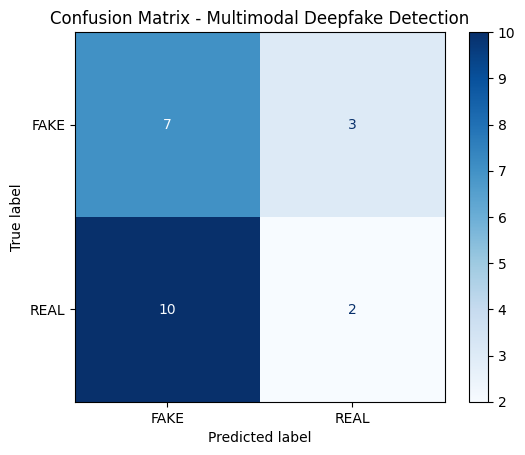

Confusion matrix saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix.png


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# Remove UNCERTAIN rows for normal binary evaluation
eval_df = final_df[final_df["predicted_label"] != "UNCERTAIN"].copy()

y_true = eval_df["true_label"]
y_pred = eval_df["predicted_label"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="REAL")
recall = recall_score(y_true, y_pred, pos_label="REAL")
f1 = f1_score(y_true, y_pred, pos_label="REAL")

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["FAKE", "REAL"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["FAKE", "REAL"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Multimodal Deepfake Detection")

conf_matrix_path = os.path.join(GRAPH_DIR, "confusion_matrix.png")
plt.savefig(conf_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", conf_matrix_path)

In [ ]:
counts = final_df["predicted_label"].value_counts()

real_count = counts.get("REAL", 0)
fake_count = counts.get("FAKE", 0)
uncertain_count = counts.get("UNCERTAIN", 0)

print("Total Predictions:")
print("REAL      :", real_count)
print("FAKE      :", fake_count)
print("UNCERTAIN :", uncertain_count)

Total Predictions:
REAL      : 5
FAKE      : 17
UNCERTAIN : 13


In [ ]:
summary_df = final_df["predicted_label"].value_counts().reset_index()
summary_df.columns = ["Label", "Count"]

print(summary_df)

       Label  Count
0       FAKE     17
1  UNCERTAIN     13
2       REAL      5


In [ ]:
print("\nSoft Voting (Simple Average) Evaluation:")
print("--------------------------------------")

eval_df = final_df[final_df["predicted_label"] != "UNCERTAIN"].copy()
y_true_soft = eval_df["true_label"]
y_pred_soft = eval_df["predicted_label"]

accuracy_soft_voting = accuracy_score(y_true_soft, y_pred_soft)
print("Accuracy :", accuracy_soft_voting)


Soft Voting (Simple Average) Evaluation:
--------------------------------------
Accuracy : 0.4090909090909091


In [ ]:
print("\nTrue Label Counts:")
print(final_df["true_label"].value_counts())


True Label Counts:
true_label
FAKE    18
REAL    17
Name: count, dtype: int64


In [ ]:
# ==============================
# WEIGHTED SCORE FUSION FUNCTION
# ==============================

def weighted_fusion_score(visual_score, audio_score, text_score,
                          visual_weight=0.50,
                          audio_weight=0.25,
                          text_weight=0.25):

    final_weighted_score = (
        visual_score * visual_weight +
        audio_score * audio_weight +
        text_score * text_weight
    )

    return final_weighted_score

In [ ]:
def classify_weighted_score(weighted_score):
    if weighted_score >= 0.60:
        return "REAL"
    elif weighted_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
visual_score = predict_visual_score(filename)
audio_score = predict_audio_score(filename)
text_score = predict_text_score(filename)

weighted_final_score = weighted_fusion_score(
    visual_score,
    audio_score,
    text_score,
    visual_weight=0.50,
    audio_weight=0.25,
    text_weight=0.25
)

predicted_label = classify_weighted_score(weighted_final_score)

In [ ]:
weighted_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_score(filename)
        audio_score = predict_audio_score(filename)
        text_score = predict_text_score(filename)

        weighted_final_score = weighted_fusion_score(
            visual_score,
            audio_score,
            text_score,
            visual_weight=0.50,
            audio_weight=0.25,
            text_weight=0.25
        )

        predicted_label = classify_weighted_score(weighted_final_score)

        if predicted_label == "UNCERTAIN":
            verdict = "Needs Human Review"
        elif predicted_label == true_label:
            verdict = "Correct"
        else:
            verdict = "Incorrect"

        explanation = (
            f"The visual score is {visual_score:.4f}, audio score is {audio_score:.4f}, "
            f"and text score is {text_score:.4f}. The weighted final score is "
            f"{weighted_final_score:.4f}. The model gives more importance to visual "
            f"features because deepfake manipulation usually appears strongly in facial "
            f"regions. Based on the weighted score, the video is classified as "
            f"{predicted_label}."
        )

        weighted_results.append({
            "filename": filename,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "weighted_final_score": weighted_final_score,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

weighted_final_df = pd.DataFrame(weighted_results)

weighted_csv_path = os.path.join(PRED_DIR, "weighted_multimodal_predictions.csv")
weighted_final_df.to_csv(weighted_csv_path, index=False)

print("Saved:", weighted_csv_path)
weighted_final_df.head()

100%|██████████| 35/35 [02:21<00:00,  4.06s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/weighted_multimodal_predictions.csv


,filename,visual_score,audio_score,text_score,weighted_final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.488450,0.295153,0.248400,0.380113,REAL,FAKE,Incorrect,"The visual score is 0.4885, audio score is 0.2..."
1,haxnhfvqvs.mp4,0.498064,0.535150,0.771157,0.575609,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.4981, audio score is 0.5..."
2,yeouperxzc.mp4,0.526788,0.719644,0.810738,0.645990,FAKE,REAL,Incorrect,"The visual score is 0.5268, audio score is 0.7..."
3,qloyrbpobv.mp4,0.492077,0.400013,0.496029,0.470049,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.4921, audio score is 0.4..."
4,qarqtkvgby.mp4,0.453725,0.365292,0.299873,0.393154,REAL,FAKE,Incorrect,"The visual score is 0.4537, audio score is 0.3..."


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

eval_weighted_df = weighted_final_df[
    weighted_final_df["predicted_label"] != "UNCERTAIN"
].copy()

y_true = eval_weighted_df["true_label"]
y_pred = eval_weighted_df["predicted_label"]

print("Weighted Voting Evaluation")
print("--------------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="REAL"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="REAL"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="REAL"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Weighted Voting Evaluation
--------------------------
Accuracy : 0.45
Precision: 0.6
Recall   : 0.25
F1 Score : 0.35294117647058826

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.40      0.75      0.52         8
        REAL       0.60      0.25      0.35        12

    accuracy                           0.45        20
   macro avg       0.50      0.50      0.44        20
weighted avg       0.52      0.45      0.42        20



In [ ]:
print("\nWeighted Voting Evaluation:")
print("--------------------------")

eval_weighted_df = weighted_final_df[
    weighted_final_df["predicted_label"] != "UNCERTAIN"
].copy()
y_true_weighted = eval_weighted_df["true_label"]
y_pred_weighted = eval_weighted_df["predicted_label"]

accuracy_weighted_voting = accuracy_score(y_true_weighted, y_pred_weighted)
print("Accuracy :", accuracy_weighted_voting)


Weighted Voting Evaluation:
--------------------------
Accuracy : 0.45


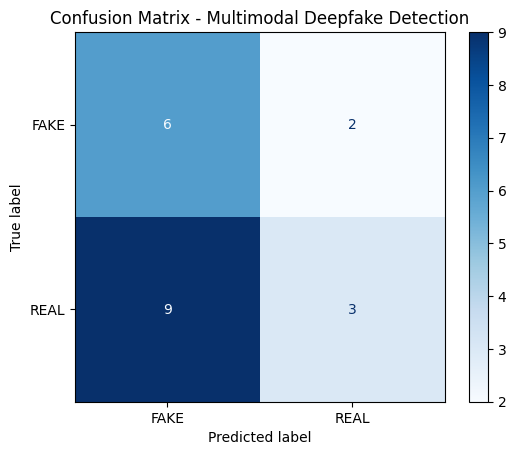

Confusion matrix saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix.png


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["FAKE", "REAL"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Multimodal Deepfake Detection")

conf_matrix_path = os.path.join(GRAPH_DIR, "confusion_matrix.png")
plt.savefig(conf_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", conf_matrix_path)

In [ ]:
def score_to_label(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
from collections import Counter

def hard_voting_label(visual_score, audio_score, text_score):
    visual_label = score_to_label(visual_score)
    audio_label = score_to_label(audio_score)
    text_label = score_to_label(text_score)

    votes = [visual_label, audio_label, text_label]
    vote_count = Counter(votes)

    # Majority vote
    most_common = vote_count.most_common()

    # If clear majority
    if most_common[0][1] >= 2:
        final_label = most_common[0][0]
    else:
        final_label = "UNCERTAIN"

    return final_label, visual_label, audio_label, text_label

In [ ]:
hard_voting_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_score(filename)
        audio_score = predict_audio_score(filename)
        text_score = predict_text_score(filename)

        final_label, visual_label, audio_label, text_label = hard_voting_label(
            visual_score,
            audio_score,
            text_score
        )

        if final_label == "UNCERTAIN":
            verdict = "Needs Human Review"
        elif final_label == true_label:
            verdict = "Correct"
        else:
            verdict = "Incorrect"

        explanation = (
            f"Visual modality voted as {visual_label}, audio modality voted as {audio_label}, "
            f"and text modality voted as {text_label}. Based on majority hard voting, "
            f"the final predicted label is {final_label}."
        )

        hard_voting_results.append({
            "filename": filename,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "visual_vote": visual_label,
            "audio_vote": audio_label,
            "text_vote": text_label,
            "true_label": true_label,
            "predicted_label": final_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

hard_voting_df = pd.DataFrame(hard_voting_results)

hard_voting_csv_path = os.path.join(PRED_DIR, "hard_voting_predictions.csv")
hard_voting_df.to_csv(hard_voting_csv_path, index=False)

print("Saved:", hard_voting_csv_path)
hard_voting_df.head()

100%|██████████| 35/35 [02:21<00:00,  4.05s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/hard_voting_predictions.csv


,filename,visual_score,audio_score,text_score,visual_vote,audio_vote,text_vote,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.488450,0.295153,0.248400,UNCERTAIN,FAKE,FAKE,REAL,FAKE,Incorrect,"Visual modality voted as UNCERTAIN, audio moda..."
1,haxnhfvqvs.mp4,0.498064,0.535150,0.771157,UNCERTAIN,UNCERTAIN,REAL,FAKE,UNCERTAIN,Needs Human Review,"Visual modality voted as UNCERTAIN, audio moda..."
2,yeouperxzc.mp4,0.526788,0.719644,0.810738,UNCERTAIN,REAL,REAL,FAKE,REAL,Incorrect,"Visual modality voted as UNCERTAIN, audio moda..."
3,qloyrbpobv.mp4,0.492077,0.400013,0.496029,UNCERTAIN,UNCERTAIN,UNCERTAIN,FAKE,UNCERTAIN,Needs Human Review,"Visual modality voted as UNCERTAIN, audio moda..."
4,qarqtkvgby.mp4,0.453725,0.365292,0.299873,UNCERTAIN,FAKE,FAKE,REAL,FAKE,Incorrect,"Visual modality voted as UNCERTAIN, audio moda..."


In [ ]:
print(hard_voting_df["predicted_label"].value_counts())

predicted_label
FAKE         17
UNCERTAIN    13
REAL          5
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

eval_hard_df = hard_voting_df[
    hard_voting_df["predicted_label"] != "UNCERTAIN"
].copy()

y_true = eval_hard_df["true_label"]
y_pred = eval_hard_df["predicted_label"]

print("Hard Voting Evaluation")
print("----------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="REAL"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="REAL"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="REAL"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Hard Voting Evaluation
----------------------
Accuracy : 0.45454545454545453
Precision: 0.6
Recall   : 0.23076923076923078
F1 Score : 0.3333333333333333

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.41      0.78      0.54         9
        REAL       0.60      0.23      0.33        13

    accuracy                           0.45        22
   macro avg       0.51      0.50      0.44        22
weighted avg       0.52      0.45      0.42        22



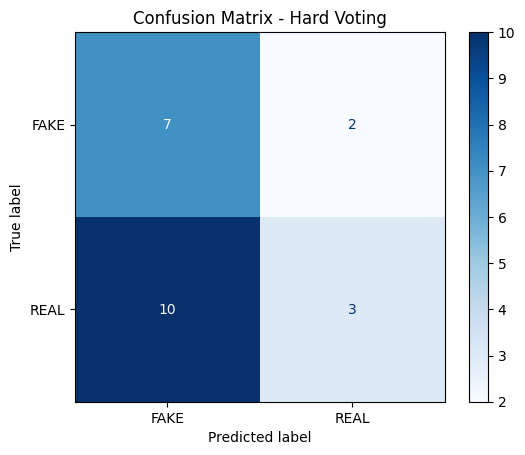

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["FAKE", "REAL"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Hard Voting")
plt.show()

In [ ]:
def classify_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
def predict_visual_max_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    frame_dir = os.path.join(FRAMES_DIR, video_name)

    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    visual_score = np.mean(all_frame_scores)

    return float(visual_score)

In [ ]:
def predict_audio_max_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)
    plp_feat = extract_plp(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]
    plp_score = plp_model.predict_proba(plp_feat)[0][1]

    audio_score = max(
        mfcc_score,
        mel_score,
        plp_score
    )

    return float(audio_score)

In [ ]:
def predict_text_max_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    transcript_path = os.path.join(TEXT_DIR, video_name + ".txt")

    with open(transcript_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    text_score = max(
        tfidf_score,
        bert_score,
        roberta_score
    )

    return float(text_score)

In [ ]:
max_fusion_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_max_score(filename)
        audio_score = predict_audio_max_score(filename)
        text_score = predict_text_max_score(filename)

        final_score = np.mean([
            visual_score,
            audio_score,
            text_score
        ])

        predicted_label = classify_score(final_score)

        if predicted_label == "UNCERTAIN":
            verdict = "Needs Human Review"
        elif predicted_label == true_label:
            verdict = "Correct"
        else:
            verdict = "Incorrect"

        explanation = (
            f"The maximum score from visual models is {visual_score:.4f}, "
            f"the maximum score from audio models is {audio_score:.4f}, "
            f"and the maximum score from text models is {text_score:.4f}. "
            f"The final score is calculated by averaging these three max scores. "
            f"The final score is {final_score:.4f}, so the prediction is {predicted_label}."
        )

        max_fusion_results.append({
            "filename": filename,
            "visual_max_score": visual_score,
            "audio_max_score": audio_score,
            "text_max_score": text_score,
            "final_score": final_score,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

max_fusion_df = pd.DataFrame(max_fusion_results)

max_fusion_csv_path = os.path.join(PRED_DIR, "max_fusion_predictions.csv")
max_fusion_df.to_csv(max_fusion_csv_path, index=False)

print("Saved:", max_fusion_csv_path)
max_fusion_df.head()

100%|██████████| 35/35 [02:23<00:00,  4.10s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/max_fusion_predictions.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.508933,0.426072,0.483914,0.472973,REAL,UNCERTAIN,Needs Human Review,The maximum score from visual models is 0.5089...
1,haxnhfvqvs.mp4,0.532602,0.627000,0.887706,0.682436,FAKE,REAL,Incorrect,The maximum score from visual models is 0.5326...
2,yeouperxzc.mp4,0.585109,0.886963,0.969539,0.813870,FAKE,REAL,Incorrect,The maximum score from visual models is 0.5851...
3,qloyrbpobv.mp4,0.505018,0.424918,0.529427,0.486454,FAKE,UNCERTAIN,Needs Human Review,The maximum score from visual models is 0.5050...
4,qarqtkvgby.mp4,0.499840,0.432043,0.393338,0.441740,REAL,UNCERTAIN,Needs Human Review,The maximum score from visual models is 0.4998...


In [ ]:
print(max_fusion_df["predicted_label"].value_counts())

predicted_label
UNCERTAIN    26
REAL          9
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

eval_max_df = max_fusion_df[
    max_fusion_df["predicted_label"] != "UNCERTAIN"
].copy()

y_true = eval_max_df["true_label"]
y_pred = eval_max_df["predicted_label"]

print("Max Fusion Evaluation")
print("---------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="REAL"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="REAL"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="REAL"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Max Fusion Evaluation
---------------------
Accuracy : 0.6666666666666666
Precision: 0.6666666666666666
Recall   : 1.0
F1 Score : 0.8

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.00      0.00      0.00         3
        REAL       0.67      1.00      0.80         6

    accuracy                           0.67         9
   macro avg       0.33      0.50      0.40         9
weighted avg       0.44      0.67      0.53         9



### Maximum Score Fusion Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["FAKE", "REAL"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Maximum Score Fusion")
plt.show()

### All Fusion Strategies Confusion Matrices

In [ ]:
# Soft Voting (Simple Average) Confusion Matrix (from cell zHe9CVpF7quX)
print("Soft Voting (Simple Average) Confusion Matrix:")

eval_df = final_df[final_df["predicted_label"] != "UNCERTAIN"].copy()
y_true_soft = eval_df["true_label"]
y_pred_soft = eval_df["predicted_label"]

cm_soft = confusion_matrix(y_true_soft, y_pred_soft, labels=["FAKE", "REAL"])
disp_soft = ConfusionMatrixDisplay(
    confusion_matrix=cm_soft,
    display_labels=["FAKE", "REAL"]
)
disp_soft.plot(cmap="Blues")
plt.title("Confusion Matrix - Soft Voting (Simple Average)")
plt.show()

# Weighted Voting Confusion Matrix (from cell nr5LLuvRNw9n)
print("\nWeighted Voting Confusion Matrix:")

eval_weighted_df = weighted_final_df[
    weighted_final_df["predicted_label"] != "UNCERTAIN"
].copy()
y_true_weighted = eval_weighted_df["true_label"]
y_pred_weighted = eval_weighted_df["predicted_label"]

cm_weighted = confusion_matrix(y_true_weighted, y_pred_weighted, labels=["FAKE", "REAL"])
disp_weighted = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=["FAKE", "REAL"]
)
disp_weighted.plot(cmap="Blues")
plt.title("Confusion Matrix - Weighted Voting")
plt.show()

# Hard Voting Confusion Matrix (from cell yrgFQNPt7qI2 and yF22lsVoOpjm)
print("\nHard Voting Confusion Matrix:")

eval_hard_df = hard_voting_df[
    hard_voting_df["predicted_label"] != "UNCERTAIN"
].copy()
y_true_hard = eval_hard_df["true_label"]
y_pred_hard = eval_hard_df["predicted_label"]

cm_hard = confusion_matrix(y_true_hard, y_pred_hard, labels=["FAKE", "REAL"])
disp_hard = ConfusionMatrixDisplay(
    confusion_matrix=cm_hard,
    display_labels=["FAKE", "REAL"]
)
disp_hard.plot(cmap="Blues")
plt.title("Confusion Matrix - Hard Voting")
plt.show()

# Maximum Score Fusion Confusion Matrix (generated above)
print("\nMaximum Score Fusion Confusion Matrix:")

eval_max_df = max_fusion_df[
    max_fusion_df["predicted_label"] != "UNCERTAIN"
].copy()
y_true_max = eval_max_df["true_label"]
y_pred_max = eval_max_df["predicted_label"]

cm_max = confusion_matrix(y_true_max, y_pred_max, labels=["FAKE", "REAL"])
disp_max = ConfusionMatrixDisplay(
    confusion_matrix=cm_max,
    display_labels=["FAKE", "REAL"]
)
disp_max.plot(cmap="Blues")
plt.title("Confusion Matrix - Maximum Score Fusion")
plt.show()


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from moviepy.editor import VideoFileClip
from tensorflow.keras.preprocessing import image
from scipy.linalg import LinAlgError # Import LinAlgError

# ===============================
# 1. EXTERNAL VIDEO PATH
# ===============================

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/trump.mp4"

external_filename = os.path.basename(EXTERNAL_VIDEO_PATH)
external_name = external_filename.replace(".mp4", "")

external_frame_dir = os.path.join(FRAMES_DIR, external_name)
external_audio_path = os.path.join(AUDIO_DIR, external_name + ".wav")
external_text_path = os.path.join(TEXT_DIR, external_name + ".txt")

os.makedirs(external_frame_dir, exist_ok=True)


# ===============================
# 2. EXTRACT FRAMES
# ===============================

def extract_external_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read video frames.")

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()

    return saved


# ===============================
# 3. EXTRACT AUDIO
# ===============================

def extract_external_audio(video_path, audio_path):
    clip = VideoFileClip(video_path)

    if clip.audio is None:
        clip.close()
        raise ValueError("No audio found in this video.")

    clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
    clip.close()

    return audio_path


# ===============================
# 4. TRANSCRIBE AUDIO
# ===============================

def transcribe_external_audio(audio_path, text_path):
    transcript = transcribe_audio(audio_path)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript


# ===============================
# 5. MAX VISUAL SCORE
# ===============================

def predict_external_visual_max_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    return float(np.mean(all_frame_scores))


# ===============================
# 6. MAX AUDIO SCORE
# ===============================

def predict_external_audio_max_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5  # Default to neutral if PLP fails
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e:  # Catch other potential errors during PLP extraction
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(max(mfcc_score, mel_score, plp_score))


# ===============================
# 7. MAX TEXT SCORE
# ===============================

def predict_external_text_max_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(max(tfidf_score, bert_score, roberta_score))


# ===============================
# 8. CLASSIFY FINAL SCORE
# ===============================

def classify_external_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


# ===============================
# 9. RUN MAXIMUM SCORE FUSION
# ===============================

print("Processing external video:", EXTERNAL_VIDEO_PATH)

frames_saved = extract_external_frames(
    EXTERNAL_VIDEO_PATH,
    external_frame_dir,
    frame_count=5
)

print("Frames extracted:", frames_saved)

extract_external_audio(
    EXTERNAL_VIDEO_PATH,
    external_audio_path
)

print("Audio extracted:", external_audio_path)

transcript = transcribe_external_audio(
    external_audio_path,
    external_text_path
)

print("Transcript saved:", external_text_path)

visual_max_score = predict_external_visual_max_score(external_frame_dir)
audio_max_score = predict_external_audio_max_score(external_audio_path)
text_max_score = predict_external_text_max_score(external_text_path)

final_score = np.mean([
    visual_max_score,
    audio_max_score,
    text_max_score
])

predicted_label = classify_external_score(final_score)

if predicted_label == "UNCERTAIN":
    verdict = "Needs Human Review"
elif predicted_label == "REAL":
    verdict = "Predicted as Real Video"
else:
    verdict = "Predicted as Fake Video"

explanation = (
    f"For this external video, the maximum visual score is {visual_max_score:.4f}, "
    f"maximum audio score is {audio_max_score:.4f}, and maximum text score is {text_max_score:.4f}. "
    f"The final score is calculated by averaging these three maximum modality scores. "
    f"The final score is {final_score:.4f}. Therefore, the video is classified as {predicted_label}."
)

external_result = {
    "filename": external_filename,
    "visual_max_score": visual_max_score,
    "audio_max_score": audio_max_score,
    "text_max_score": text_max_score,
    "final_score": final_score,
    "true_label": "Unknown",
    "predicted_label": predicted_label,
    "verdict": verdict,
    "explanation": explanation
}

external_result_df = pd.DataFrame([external_result])

external_csv_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction.csv"
)

external_result_df.to_csv(external_csv_path, index=False)

print("Saved:", external_csv_path)
external_result_df

Processing external video: /content/drive/MyDrive/trump.mp4
Frames extracted: 5


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/trump.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/trump.txt
LinAlgError during PLP extraction for /content/drive/MyDrive/Deepfake_Project/data/processed/audio/trump.wav: singular matrix. Using neutral PLP score (0.5).
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,trump.mp4,0.748134,0.96648,0.977677,0.89743,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path = "Not generated"

try:
    # Get the mobilenet model
    mobilenet_model = visual_models["mobilenet"]

    # Get the first frame from the external video's frame directory
    first_external_frame = os.listdir(external_frame_dir)[0]
    external_frame_path = os.path.join(external_frame_dir, first_external_frame)

    # Define the save path for the external video's Grad-CAM image
    external_gradcam_save_path = os.path.join(EXPLAIN_DIR, external_name + "_gradcam.jpg")

    # Generate and save the Grad-CAM image
    external_gradcam_path = save_gradcam(
        external_frame_path,
        mobilenet_model,
        external_gradcam_save_path,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)

# Add the Grad-CAM image path to the external_result_df
external_result_df["gradcam_image_path"] = external_gradcam_path

# Save the updated DataFrame to a new CSV file
external_csv_with_gradcam_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction_with_gradcam.csv"
)
external_result_df.to_csv(external_csv_with_gradcam_path, index=False)

print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path)
display(external_result_df)

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/trump_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,trump.mp4,0.748134,0.96648,0.977677,0.89743,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


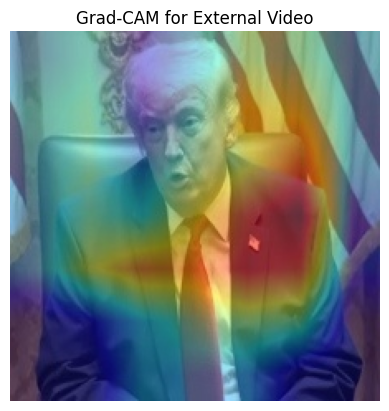

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if external_gradcam_path != "Not generated" and os.path.exists(external_gradcam_path):
    img = mpimg.imread(external_gradcam_path)
    plt.imshow(img)
    plt.axis('off') # Hide axes ticks
    plt.title('Grad-CAM for External Video')
    plt.show()
else:
    print("Grad-CAM image not found or not generated.")

### Processing a FAKE video that was predicted as UNCERTAIN (Max-Fusion)

As previously discussed, the model shows a bias towards 'REAL' or 'UNCERTAIN' predictions, with no confident 'FAKE' predictions (score <= 0.40) in the test set using the max-fusion strategy. We will now examine a 'FAKE' video from the test set that was classified as 'UNCERTAIN' by the max-fusion strategy to understand the model's behavior.

We will use `qloyrbpobv.mp4` as identified from the `max_fusion_df` (index 3: true_label: FAKE, predicted_label: UNCERTAIN, final_score: 0.5355).

In [ ]:
target_video_filename_uncertain_fake = 'qloyrbpobv.mp4'
EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE = os.path.join(RAW_DIR, target_video_filename_uncertain_fake)

external_filename_uncertain_fake = os.path.basename(EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE)
external_name_uncertain_fake = external_filename_uncertain_fake.replace(".mp4", "")

external_frame_dir_uncertain_fake = os.path.join(FRAMES_DIR, external_name_uncertain_fake)
external_audio_path_uncertain_fake = os.path.join(AUDIO_DIR, external_name_uncertain_fake + ".wav")
external_text_path_uncertain_fake = os.path.join(TEXT_DIR, external_name_uncertain_fake + ".txt")

os.makedirs(external_frame_dir_uncertain_fake, exist_ok=True)

print("Processing external video:", EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE)

try:
    frames_saved_uncertain_fake = extract_external_frames(
        EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE,
        external_frame_dir_uncertain_fake,
        frame_count=5
    )
    print("Frames extracted:", frames_saved_uncertain_fake)

    extract_external_audio(
        EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE,
        external_audio_path_uncertain_fake
    )
    print("Audio extracted:", external_audio_path_uncertain_fake)

    transcript_uncertain_fake = transcribe_external_audio(
        external_audio_path_uncertain_fake,
        external_text_path_uncertain_fake
    )
    print("Transcript saved:", external_text_path_uncertain_fake)

    # Use the max-fusion prediction functions
    visual_max_score_uncertain_fake = predict_external_visual_max_score(external_frame_dir_uncertain_fake)
    audio_max_score_uncertain_fake = predict_external_audio_max_score(external_audio_path_uncertain_fake)
    text_max_score_uncertain_fake = predict_external_text_max_score(external_text_path_uncertain_fake)

    final_score_uncertain_fake = np.mean([
        visual_max_score_uncertain_fake,
        audio_max_score_uncertain_fake,
        text_max_score_uncertain_fake
    ])

    predicted_label_uncertain_fake = classify_external_score(final_score_uncertain_fake)

    if predicted_label_uncertain_fake == "UNCERTAIN":
        verdict_uncertain_fake = "Needs Human Review"
    elif predicted_label_uncertain_fake == "REAL":
        verdict_uncertain_fake = "Predicted as Real Video"
    else:
        verdict_uncertain_fake = "Predicted as Fake Video"

    explanation_uncertain_fake = (
        f"For this external video, the maximum visual score is {visual_max_score_uncertain_fake:.4f}, "
        f"maximum audio score is {audio_max_score_uncertain_fake:.4f}, and maximum text score is {text_max_score_uncertain_fake:.4f}. "
        f"The final score is calculated by averaging these three maximum modality scores. "
        f"The final score is {final_score_uncertain_fake:.4f}. Therefore, the video is classified as {predicted_label_uncertain_fake}."
    )

    external_result_uncertain_fake = {
        "filename": external_filename_uncertain_fake,
        "visual_max_score": visual_max_score_uncertain_fake,
        "audio_max_score": audio_max_score_uncertain_fake,
        "text_max_score": text_max_score_uncertain_fake,
        "final_score": final_score_uncertain_fake,
        "true_label": "FAKE", # Explicitly set true label for this scenario
        "predicted_label": predicted_label_uncertain_fake,
        "verdict": verdict_uncertain_fake,
        "explanation": explanation_uncertain_fake
    }

    external_result_df_uncertain_fake = pd.DataFrame([external_result_uncertain_fake])

    external_csv_path_uncertain_fake = os.path.join(
        PRED_DIR,
        "external_video_max_fusion_prediction_uncertain_fake.csv"
    )

    external_result_df_uncertain_fake.to_csv(external_csv_path_uncertain_fake, index=False)

    print("Saved:", external_csv_path_uncertain_fake)
    display(external_result_df_uncertain_fake)

except Exception as e:
    print(f"An error occurred during processing: {e}")

Processing external video: /content/drive/MyDrive/Deepfake_Project/data/raw/dfdc_train_part_00/qloyrbpobv.mp4
Frames extracted: 5


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/qloyrbpobv.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/qloyrbpobv.txt
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_uncertain_fake.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,qloyrbpobv.mp4,0.593365,0.48344,0.530076,0.535627,FAKE,UNCERTAIN,Needs Human Review,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path_uncertain_fake = "Not generated"

try:
    # Get the mobilenet model
    mobilenet_model = visual_models["mobilenet"]

    # Get the first frame from the external video's frame directory
    first_external_frame_uncertain_fake = os.listdir(external_frame_dir_uncertain_fake)[0]
    external_frame_path_uncertain_fake = os.path.join(external_frame_dir_uncertain_fake, first_external_frame_uncertain_fake)

    # Define the save path for the external video's Grad-CAM image
    external_gradcam_save_path_uncertain_fake = os.path.join(EXPLAIN_DIR, external_name_uncertain_fake + "_gradcam.jpg")

    # Generate and save the Grad-CAM image
    external_gradcam_path_uncertain_fake = save_gradcam(
        external_frame_path_uncertain_fake,
        mobilenet_model,
        external_gradcam_save_path_uncertain_fake,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path_uncertain_fake)

except Exception as e:
    print("Grad-CAM error for external video:", e)

# Add the Grad-CAM image path to the external_result_df
if 'external_result_df_uncertain_fake' in locals():
    external_result_df_uncertain_fake["gradcam_image_path"] = external_gradcam_path_uncertain_fake

    # Save the updated DataFrame to a new CSV file
    external_csv_with_gradcam_path_uncertain_fake = os.path.join(
        PRED_DIR,
        "external_video_max_fusion_prediction_uncertain_fake_with_gradcam.csv"
    )
    external_result_df_uncertain_fake.to_csv(external_csv_with_gradcam_path_uncertain_fake, index=False)

    print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path_uncertain_fake)
    display(external_result_df_uncertain_fake)
else:
    print("external_result_df_uncertain_fake not found, cannot add gradcam_image_path.")

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/qloyrbpobv_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_uncertain_fake_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,qloyrbpobv.mp4,0.593365,0.48344,0.530076,0.535627,FAKE,UNCERTAIN,Needs Human Review,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


Displaying Grad-CAM for the uncertain fake video:


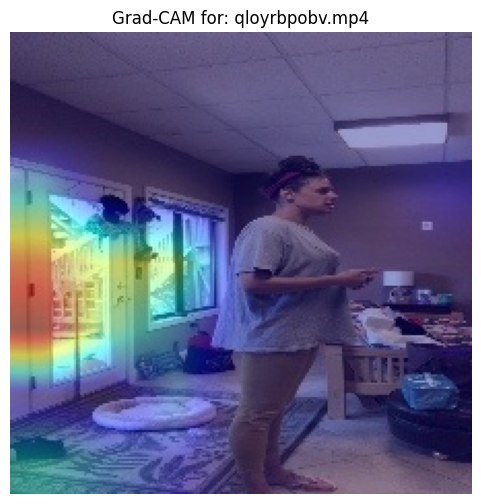

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

if 'external_gradcam_path_uncertain_fake' in locals() and os.path.exists(external_gradcam_path_uncertain_fake):
    print("Displaying Grad-CAM for the uncertain fake video:")
    img = mpimg.imread(external_gradcam_path_uncertain_fake)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide axes ticks
    plt.title(f'Grad-CAM for: {external_name_uncertain_fake}.mp4')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the uncertain fake video.")

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from moviepy.editor import VideoFileClip
from tensorflow.keras.preprocessing import image
from scipy.linalg import LinAlgError # Import LinAlgError

# ===============================
# 1. EXTERNAL VIDEO PATH
# ===============================

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/my.mp4"

external_filename = os.path.basename(EXTERNAL_VIDEO_PATH)
external_name = external_filename.replace(".mp4", "")

external_frame_dir = os.path.join(FRAMES_DIR, external_name)
external_audio_path = os.path.join(AUDIO_DIR, external_name + ".wav")
external_text_path = os.path.join(TEXT_DIR, external_name + ".txt")

os.makedirs(external_frame_dir, exist_ok=True)


# ===============================
# 2. EXTRACT FRAMES
# ===============================

def extract_external_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}. Check if the path is correct and the video format is supported.")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read video frames.")

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()

    return saved


# ===============================
# 3. EXTRACT AUDIO
# ===============================

def extract_external_audio(video_path, audio_path):
    clip = VideoFileClip(video_path)

    if clip.audio is None:
        clip.close()
        raise ValueError("No audio found in this video.")

    clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
    clip.close()

    return audio_path


# ===============================
# 4. TRANSCRIBE AUDIO
# ===============================

def transcribe_external_audio(audio_path, text_path):
    transcript = transcribe_audio(audio_path)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript


# ===============================
# 5. MAX VISUAL SCORE
# ===============================

def predict_external_visual_max_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    return float(np.mean(all_frame_scores))


# ===============================
# 6. MAX AUDIO SCORE
# ===============================

def predict_external_audio_max_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5  # Default to neutral if PLP fails
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e:  # Catch other potential errors during PLP extraction
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(max(mfcc_score, mel_score, plp_score))


# ===============================
# 7. MAX TEXT SCORE
# ===============================

def predict_external_text_max_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(max(tfidf_score, bert_score, roberta_score))


# ===============================
# 8. CLASSIFY FINAL SCORE
# ===============================

def classify_external_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


# ===============================
# 9. RUN MAXIMUM SCORE FUSION
# ===============================

print("Processing external video:", EXTERNAL_VIDEO_PATH)

frames_saved = extract_external_frames(
    EXTERNAL_VIDEO_PATH,
    external_frame_dir,
    frame_count=5
)

print("Frames extracted:", frames_saved)

extract_external_audio(
    EXTERNAL_VIDEO_PATH,
    external_audio_path
)

print("Audio extracted:", external_audio_path)

transcript = transcribe_external_audio(
    external_audio_path,
    external_text_path
)

print("Transcript saved:", external_text_path)

visual_max_score = predict_external_visual_max_score(external_frame_dir)
audio_max_score = predict_external_audio_max_score(external_audio_path)
text_max_score = predict_external_text_max_score(external_text_path)

final_score = np.mean([
    visual_max_score,
    audio_max_score,
    text_max_score
])

predicted_label = classify_external_score(final_score)

if predicted_label == "UNCERTAIN":
    verdict = "Needs Human Review"
elif predicted_label == "REAL":
    verdict = "Predicted as Real Video"
else:
    verdict = "Predicted as Fake Video"

explanation = (
    f"For this external video, the maximum visual score is {visual_max_score:.4f}, "
    f"maximum audio score is {audio_max_score:.4f}, and maximum text score is {text_max_score:.4f}. "
    f"The final score is calculated by averaging these three maximum modality scores. "
    f"The final score is {final_score:.4f}. Therefore, the video is classified as {predicted_label}."
)

external_result = {
    "filename": external_filename,
    "visual_max_score": visual_max_score,
    "audio_max_score": audio_max_score,
    "text_max_score": text_max_score,
    "final_score": final_score,
    "true_label": "Unknown",
    "predicted_label": predicted_label,
    "verdict": verdict,
    "explanation": explanation
}

external_result_df = pd.DataFrame([external_result])

external_csv_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction.csv"
)

external_result_df.to_csv(external_csv_path, index=False)

print("Saved:", external_csv_path)
display(external_result_df)

Processing external video: /content/drive/MyDrive/my.mp4
Frames extracted: 5
Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/my.txt
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,my.mp4,0.626449,0.809611,0.786613,0.740891,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path = "Not generated"

try:
    # Get the mobilenet model
    mobilenet_model = visual_models["mobilenet"]

    # Get the first frame from the external video's frame directory
    first_external_frame = os.listdir(external_frame_dir)[0]
    external_frame_path = os.path.join(external_frame_dir, first_external_frame)

    # Define the save path for the external video's Grad-CAM image
    external_gradcam_save_path = os.path.join(EXPLAIN_DIR, external_name + "_gradcam.jpg")

    # Generate and save the Grad-CAM image
    external_gradcam_path = save_gradcam(
        external_frame_path,
        mobilenet_model,
        external_gradcam_save_path,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)

# Add the Grad-CAM image path to the external_result_df
external_result_df["gradcam_image_path"] = external_gradcam_path

# Save the updated DataFrame to a new CSV file
external_csv_with_gradcam_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction_with_gradcam.csv"
)
external_result_df.to_csv(external_csv_with_gradcam_path, index=False)

print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path)
display(external_result_df)

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,my.mp4,0.676137,0.80763,0.613667,0.699145,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


Displaying Grad-CAM for the last processed external video:


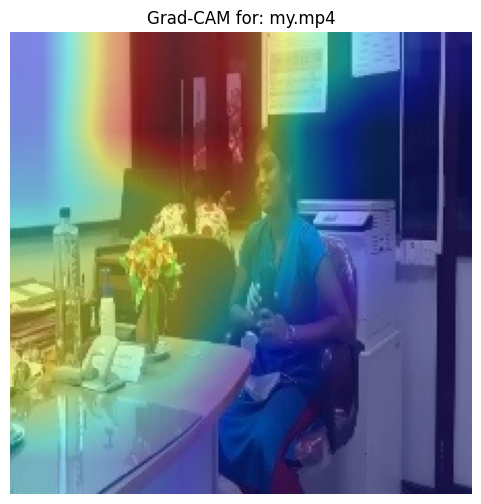

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Ensure external_gradcam_path is defined and points to a valid file
# This variable should hold the path to the most recently generated Grad-CAM image

if 'external_gradcam_path' in locals() and os.path.exists(external_gradcam_path):
    print("Displaying Grad-CAM for the last processed external video:")
    img = mpimg.imread(external_gradcam_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide axes ticks
    plt.title(f'Grad-CAM for: {external_name}.mp4')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the last processed external video.")


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from moviepy.editor import VideoFileClip
from tensorflow.keras.preprocessing import image
from scipy.linalg import LinAlgError # Import LinAlgError

# ===============================
# 1. EXTERNAL VIDEO PATH
# ===============================

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/my3.mp4"

external_filename = os.path.basename(EXTERNAL_VIDEO_PATH)
external_name = external_filename.replace(".mp4", "")

external_frame_dir = os.path.join(FRAMES_DIR, external_name)
external_audio_path = os.path.join(AUDIO_DIR, external_name + ".wav")
external_text_path = os.path.join(TEXT_DIR, external_name + ".txt")

os.makedirs(external_frame_dir, exist_ok=True)


# ===============================
# 2. EXTRACT FRAMES
# ===============================

def extract_external_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}. Check if the path is correct and the video format is supported.")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read video frames.")

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()

    return saved


# ===============================
# 3. EXTRACT AUDIO
# ===============================

def extract_external_audio(video_path, audio_path):
    clip = VideoFileClip(video_path)

    if clip.audio is None:
        clip.close()
        raise ValueError("No audio found in this video.")

    clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
    clip.close()

    return audio_path


# ===============================
# 4. TRANSCRIBE AUDIO
# ===============================

def transcribe_external_audio(audio_path, text_path):
    transcript = transcribe_audio(audio_path)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript


# ===============================
# 5. MAX VISUAL SCORE
# ===============================

def predict_external_visual_max_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    return float(np.mean(all_frame_scores))


# ===============================
# 6. MAX AUDIO SCORE
# ===============================

def predict_external_audio_max_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5  # Default to neutral if PLP fails
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e:  # Catch other potential errors during PLP extraction
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(max(mfcc_score, mel_score, plp_score))


# ===============================
# 7. MAX TEXT SCORE
# ===============================

def predict_external_text_max_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(max(tfidf_score, bert_score, roberta_score))


# ===============================
# 8. CLASSIFY FINAL SCORE
# ===============================

def classify_external_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


# ===============================
# 9. RUN MAXIMUM SCORE FUSION
# ===============================

print("Processing external video:", EXTERNAL_VIDEO_PATH)

frames_saved = extract_external_frames(
    EXTERNAL_VIDEO_PATH,
    external_frame_dir,
    frame_count=5
)

print("Frames extracted:", frames_saved)

extract_external_audio(
    EXTERNAL_VIDEO_PATH,
    external_audio_path
)

print("Audio extracted:", external_audio_path)

transcript = transcribe_external_audio(
    external_audio_path,
    external_text_path
)

print("Transcript saved:", external_text_path)

visual_max_score = predict_external_visual_max_score(external_frame_dir)
audio_max_score = predict_external_audio_max_score(external_audio_path)
text_max_score = predict_external_text_max_score(external_text_path)

final_score = np.mean([
    visual_max_score,
    audio_max_score,
    text_max_score
])

predicted_label = classify_external_score(final_score)

if predicted_label == "UNCERTAIN":
    verdict = "Needs Human Review"
elif predicted_label == "REAL":
    verdict = "Predicted as Real Video"
else:
    verdict = "Predicted as Fake Video"

explanation = (
    f"For this external video, the maximum visual score is {visual_max_score:.4f}, "
    f"maximum audio score is {audio_max_score:.4f}, and maximum text score is {text_max_score:.4f}. "
    f"The final score is calculated by averaging these three maximum modality scores. "
    f"The final score is {final_score:.4f}. Therefore, the video is classified as {predicted_label}."
)

external_result = {
    "filename": external_filename,
    "visual_max_score": visual_max_score,
    "audio_max_score": audio_max_score,
    "text_max_score": text_max_score,
    "final_score": final_score,
    "true_label": "Unknown",
    "predicted_label": predicted_label,
    "verdict": verdict,
    "explanation": explanation
}

external_result_df = pd.DataFrame([external_result])

external_csv_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction.csv"
)

external_result_df.to_csv(external_csv_path, index=False)

print("Saved:", external_csv_path)
display(external_result_df)

Processing external video: /content/drive/MyDrive/my3.mp4
Frames extracted: 5
Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my3.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/my3.txt
LinAlgError during PLP extraction for /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my3.wav: singular matrix. Using neutral PLP score (0.5).
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,my3.mp4,0.625664,0.5,0.889238,0.671634,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path = "Not generated"

try:
    # Get the mobilenet model
    mobilenet_model = visual_models["mobilenet"]

    # Get the first frame from the external video's frame directory
    first_external_frame = os.listdir(external_frame_dir)[0]
    external_frame_path = os.path.join(external_frame_dir, first_external_frame)

    # Define the save path for the external video's Grad-CAM image
    external_gradcam_save_path = os.path.join(EXPLAIN_DIR, external_name + "_gradcam.jpg")

    # Generate and save the Grad-CAM image
    external_gradcam_path = save_gradcam(
        external_frame_path,
        mobilenet_model,
        external_gradcam_save_path,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)

# Add the Grad-CAM image path to the external_result_df
external_result_df["gradcam_image_path"] = external_gradcam_path

# Save the updated DataFrame to a new CSV file
external_csv_with_gradcam_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction_with_gradcam.csv"
)
external_result_df.to_csv(external_csv_with_gradcam_path, index=False)

print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path)
display(external_result_df)

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my3_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,my3.mp4,0.625664,0.5,0.889238,0.671634,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


Displaying Grad-CAM for the last processed external video:


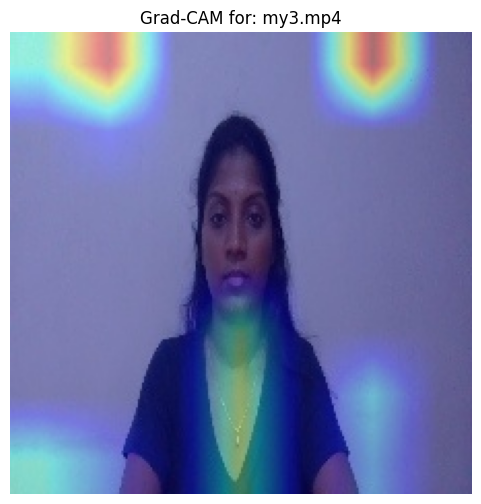

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Ensure external_gradcam_path is defined and points to a valid file
# This variable should hold the path to the most recently generated Grad-CAM image

if 'external_gradcam_path' in locals() and os.path.exists(external_gradcam_path):
    print("Displaying Grad-CAM for the last processed external video:")
    img = mpimg.imread(external_gradcam_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide axes ticks
    plt.title(f'Grad-CAM for: {external_name}.mp4')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the last processed external video.")


### Comparison of Fusion Strategies

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Prepare a dictionary to store results
comparison_results = {}

def evaluate_strategy(df, strategy_name):
    eval_df = df[df["predicted_label"] != "UNCERTAIN"].copy()

    if not eval_df.empty:
        y_true = eval_df["true_label"]
        y_pred = eval_df["predicted_label"]

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, pos_label="REAL", zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label="REAL", zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label="REAL", zero_division=0)

        comparison_results[strategy_name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        }
    else:
        comparison_results[strategy_name] = {
            "Accuracy": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
            "F1-Score": 0.0
        }

# Evaluate each strategy using the previously generated dataframes
# Note: eval_df, eval_weighted_df, eval_hard_df, eval_max_df already exist

# Average (Soft Voting)
if 'final_df' in locals():
    evaluate_strategy(final_df, "Average (Soft Voting)")

# Weighted (Soft Voting)
if 'weighted_final_df' in locals():
    evaluate_strategy(weighted_final_df, "Weighted (Soft Voting)")

# Hard Voting
if 'hard_voting_df' in locals():
    evaluate_strategy(hard_voting_df, "Hard Voting")

# Maximum Score Fusion
if 'max_fusion_df' in locals():
    evaluate_strategy(max_fusion_df, "Maximum Score Fusion")

# Convert results to DataFrame for better display
comparison_df = pd.DataFrame.from_dict(comparison_results, orient='index')
comparison_df.index.name = "Strategy"

display(comparison_df.round(4))


,Accuracy,Precision,Recall,F1-Score
Strategy,,,,
Average (Soft Voting),0.4091,0.4000,0.1667,0.2353
Weighted (Soft Voting),0.4500,0.6000,0.2500,0.3529
Hard Voting,0.4545,0.6000,0.2308,0.3333
Maximum Score Fusion,0.6667,0.6667,1.0000,0.8000


### Testing a Video from Test Data Using Soft Voting

In [ ]:
single_test_video = test_df.iloc[0]
filename_to_test = single_test_video['filename']
true_label_to_test = single_test_video['label']

print(f"Processing video: {filename_to_test} (True Label: {true_label_to_test})")

try:
    # Predict scores for each modality
    visual_score_test = predict_visual_score(filename_to_test)
    audio_score_test = predict_audio_score(filename_to_test)
    text_score_test = predict_text_score(filename_to_test)

    # Calculate final soft voting score
    final_score_test = np.mean([
        visual_score_test,
        audio_score_test,
        text_score_test
    ])

    # Classify the final score
    predicted_label_test = classify_final_score(final_score_test)

    # Determine verdict
    if predicted_label_test == "UNCERTAIN":
        verdict_test = "Needs Human Review"
    elif predicted_label_test == true_label_to_test:
        verdict_test = "Correct"
    else:
        verdict_test = "Incorrect"

    # Generate explanation
    explanation_test = generate_verdict_explanation(
        visual_score_test,
        audio_score_test,
        text_score_test,
        final_score_test,
        predicted_label_test
    )

    # Store results in a dictionary
    test_video_result = {
        "filename": filename_to_test,
        "visual_score": visual_score_test,
        "audio_score": audio_score_test,
        "text_score": text_score_test,
        "final_score": final_score_test,
        "true_label": true_label_to_test,
        "predicted_label": predicted_label_test,
        "verdict": verdict_test,
        "explanation": explanation_test
    }

    # Create a DataFrame for display
    test_video_df = pd.DataFrame([test_video_result])

    display(test_video_df)

except Exception as e:
    print(f"An error occurred during processing: {e}")

Processing video: dhjnjkzuhq.mp4 (True Label: REAL)


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.48845,0.295153,0.2484,0.344001,REAL,REAL,Correct,"The visual score is 0.4885, audio score is 0.2..."


### Grad-CAM for the Test Video (Soft Voting)

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for test video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/dhjnjkzuhq_soft_voting_gradcam.jpg
Displaying Grad-CAM for the test video:


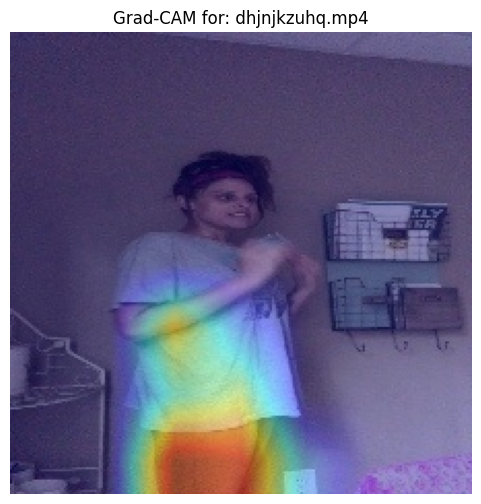

In [ ]:
test_video_gradcam_path = "Not generated"

try:
    # Get the mobilenet model (assuming it's a representative visual model)
    mobilenet_model = visual_models["mobilenet"]

    # Get the frame directory for the test video
    test_video_name = filename_to_test.replace(".mp4", "")
    test_video_frame_dir = os.path.join(FRAMES_DIR, test_video_name)

    # Ensure frames are extracted (this was already done earlier for test_df, but good to ensure)
    if not os.path.exists(test_video_frame_dir) or not os.listdir(test_video_frame_dir):
        _ = extract_external_frames(single_test_video["video_path"], test_video_frame_dir, frame_count=5)

    # Get the first frame from the test video's frame directory
    first_test_frame = os.listdir(test_video_frame_dir)[0]
    test_frame_path = os.path.join(test_video_frame_dir, first_test_frame)

    # Define the save path for the test video's Grad-CAM image
    test_gradcam_save_path = os.path.join(EXPLAIN_DIR, test_video_name + "_soft_voting_gradcam.jpg")

    # Generate and save the Grad-CAM image
    test_video_gradcam_path = save_gradcam(
        test_frame_path,
        mobilenet_model,
        test_gradcam_save_path,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for test video:", test_video_gradcam_path)

except Exception as e:
    print("Grad-CAM error for test video:", e)

# Display the Grad-CAM image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if 'test_video_gradcam_path' in locals() and os.path.exists(test_video_gradcam_path):
    print("Displaying Grad-CAM for the test video:")
    img = mpimg.imread(test_video_gradcam_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide axes ticks
    plt.title(f'Grad-CAM for: {filename_to_test}')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the test video.")

### Testing an External Video from Drive Using Soft Voting with Grad-CAM

In [ ]:
EXTERNAL_VIDEO_PATH_SOFT_VOTING = "/content/drive/MyDrive/my.mp4" # @param {type:"string"}

external_filename_sv = os.path.basename(EXTERNAL_VIDEO_PATH_SOFT_VOTING)
external_name_sv = external_filename_sv.replace(".mp4", "")

external_frame_dir_sv = os.path.join(FRAMES_DIR, external_name_sv)
external_audio_path_sv = os.path.join(AUDIO_DIR, external_name_sv + ".wav")
external_text_path_sv = os.path.join(TEXT_DIR, external_name_sv + ".txt")

os.makedirs(external_frame_dir_sv, exist_ok=True)


def predict_external_visual_soft_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        model_scores = []
        for model_name, model in visual_models.items():
            score = model.predict(img_arr, verbose=0)[0][0]
            model_scores.append(score)

        all_frame_scores.append(np.mean(model_scores))

    return float(np.mean(all_frame_scores))

def predict_external_audio_soft_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5  # Default to neutral if PLP fails
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e:  # Catch other potential errors during PLP extraction
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(np.mean([mfcc_score, mel_score, plp_score]))

def predict_external_text_soft_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(np.mean([tfidf_score, bert_score, roberta_score]))


print("Processing external video (Soft Voting):", EXTERNAL_VIDEO_PATH_SOFT_VOTING)

try:
    # 1. Extract frames
    frames_saved_sv = extract_external_frames(
        EXTERNAL_VIDEO_PATH_SOFT_VOTING,
        external_frame_dir_sv,
        frame_count=5
    )
    print("Frames extracted:", frames_saved_sv)

    # 2. Extract audio
    extract_external_audio(
        EXTERNAL_VIDEO_PATH_SOFT_VOTING,
        external_audio_path_sv
    )
    print("Audio extracted:", external_audio_path_sv)

    # 3. Transcribe audio
    transcript_sv = transcribe_external_audio(
        external_audio_path_sv,
        external_text_path_sv
    )
    print("Transcript saved:", external_text_path_sv)

    # 4. Predict scores using soft voting functions
    visual_score_sv = predict_external_visual_soft_score(external_frame_dir_sv)
    audio_score_sv = predict_external_audio_soft_score(external_audio_path_sv)
    text_score_sv = predict_external_text_soft_score(external_text_path_sv)

    # 5. Calculate final soft voting score
    final_score_sv = np.mean([
        visual_score_sv,
        audio_score_sv,
        text_score_sv
    ])

    # 6. Classify and generate explanation (using existing functions)
    predicted_label_sv = classify_final_score(final_score_sv)

    verdict_sv = "Needs Human Review"
    if predicted_label_sv == "REAL":
        verdict_sv = "Predicted as Real Video"
    elif predicted_label_sv == "FAKE":
        verdict_sv = "Predicted as Fake Video"

    explanation_sv = generate_verdict_explanation(
        visual_score_sv,
        audio_score_sv,
        text_score_sv,
        final_score_sv,
        predicted_label_sv
    )

    external_soft_voting_result = {
        "filename": external_filename_sv,
        "visual_score": visual_score_sv,
        "audio_score": audio_score_sv,
        "text_score": text_score_sv,
        "final_score": final_score_sv,
        "true_label": "Unknown",
        "predicted_label": predicted_label_sv,
        "verdict": verdict_sv,
        "explanation": explanation_sv
    }

    external_soft_voting_df = pd.DataFrame([external_soft_voting_result])

    external_soft_voting_csv_path = os.path.join(
        PRED_DIR,
        "external_video_soft_voting_prediction.csv"
    )

    external_soft_voting_df.to_csv(external_soft_voting_csv_path, index=False)

    print("Saved external soft voting prediction to:", external_soft_voting_csv_path)
    display(external_soft_voting_df)

except Exception as e:
    print(f"An error occurred during soft voting prediction: {e}")

Processing external video (Soft Voting): /content/drive/MyDrive/my.mp4
Frames extracted: 5
Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/my.txt
Saved external soft voting prediction to: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_soft_voting_prediction.csv


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation
0,my.mp4,0.559958,0.604219,0.415181,0.526453,Unknown,UNCERTAIN,Needs Human Review,"The visual score is 0.5600, audio score is 0.6..."


Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my_soft_voting_gradcam.jpg
Displaying Grad-CAM for the external video:


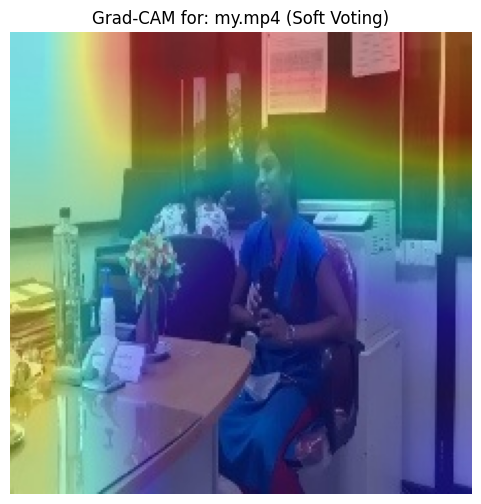

In [ ]:
external_soft_voting_gradcam_path = "Not generated"

try:
    # Get the mobilenet model (assuming it's a representative visual model)
    mobilenet_model = visual_models["mobilenet"]

    # Get the first frame from the external video's frame directory
    first_external_frame_sv = os.listdir(external_frame_dir_sv)[0]
    external_frame_path_sv = os.path.join(external_frame_dir_sv, first_external_frame_sv)

    # Define the save path for the external video's Grad-CAM image
    external_gradcam_save_path_sv = os.path.join(EXPLAIN_DIR, external_name_sv + "_soft_voting_gradcam.jpg")

    # Generate and save the Grad-CAM image
    external_soft_voting_gradcam_path = save_gradcam(
        external_frame_path_sv,
        mobilenet_model,
        external_gradcam_save_path_sv,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_soft_voting_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)

# Display the Grad-CAM image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if 'external_soft_voting_gradcam_path' in locals() and os.path.exists(external_soft_voting_gradcam_path):
    print("Displaying Grad-CAM for the external video:")
    img = mpimg.imread(external_soft_voting_gradcam_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide axes ticks
    plt.title(f'Grad-CAM for: {external_filename_sv} (Soft Voting)')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the external video (Soft Voting).")

### Audio Models Comparison

### Text Models Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

text_model_comparison_results = {}

# Re-split text data to get consistent X_test, y_test for all metrics
# The text_df, tfidf_model, bert_clf, roberta_clf, bert_embedder, roberta_embedder
# are assumed to be available from previous cells.

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    text_df["transcript"],
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

# Evaluate TF-IDF model
y_pred_tfidf = tfidf_model.predict(X_test_text)
text_model_comparison_results["TF-IDF Model"] = {
    "Accuracy": accuracy_score(y_test_text, y_pred_tfidf),
    "Precision": precision_score(y_test_text, y_pred_tfidf, pos_label=1, zero_division=0),
    "Recall": recall_score(y_test_text, y_pred_tfidf, pos_label=1, zero_division=0),
    "F1-Score": f1_score(y_test_text, y_pred_tfidf, pos_label=1, zero_division=0)
}

# Evaluate BERT model
# Generate BERT embeddings for the test set
X_test_bert_embeddings = bert_embedder.encode(
    X_test_text.tolist(),
    show_progress_bar=False
)
y_pred_bert = bert_clf.predict(X_test_bert_embeddings)
text_model_comparison_results["BERT Model"] = {
    "Accuracy": accuracy_score(y_test_text, y_pred_bert),
    "Precision": precision_score(y_test_text, y_pred_bert, pos_label=1, zero_division=0),
    "Recall": recall_score(y_test_text, y_pred_bert, pos_label=1, zero_division=0),
    "F1-Score": f1_score(y_test_text, y_pred_bert, pos_label=1, zero_division=0)
}

# Evaluate RoBERTa model
# Generate RoBERTa embeddings for the test set
X_test_roberta_embeddings = roberta_embedder.encode(
    X_test_text.tolist(),
    show_progress_bar=False
)
y_pred_roberta = roberta_clf.predict(X_test_roberta_embeddings)
text_model_comparison_results["RoBERTa Model"] = {
    "Accuracy": accuracy_score(y_test_text, y_pred_roberta),
    "Precision": precision_score(y_test_text, y_pred_roberta, pos_label=1, zero_division=0),
    "Recall": recall_score(y_test_text, y_pred_roberta, pos_label=1, zero_division=0),
    "F1-Score": f1_score(y_test_text, y_pred_roberta, pos_label=1, zero_division=0)
}

# Convert results to DataFrame for better display
text_comparison_df = pd.DataFrame.from_dict(text_model_comparison_results, orient='index')
text_comparison_df.index.name = "Text Model"

display(text_comparison_df.round(4))

### Text Model Performance Comparison

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'text_comparison_df' in locals() and not text_comparison_df.empty:
    # Plotting the comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Text Model Performance Comparison', fontsize=16)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    for i, metric in enumerate(metrics):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        sns.barplot(x=text_comparison_df.index, y=metric, data=text_comparison_df, ax=ax, palette='viridis')
        ax.set_title(metric)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No text model comparison data available to plot.")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

audio_model_comparison_results = {}

# Prepare test data for audio models
# This recreates the test set similar to how it was split during training

def get_audio_features_for_test(test_df):
    test_audio_rows = []
    for _, row in test_df.iterrows():
        video_name = row["filename"].replace(".mp4", "")
        audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

        if os.path.exists(audio_path):
            try:
                mfcc_feat = extract_mfcc(audio_path)
                mel_feat = extract_mel(audio_path)
                plp_feat = extract_plp(audio_path)

                test_audio_rows.append({
                    "filename": row["filename"],
                    "label_num": row["label_num"],
                    "mfcc": mfcc_feat,
                    "mel": mel_feat,
                    "plp": plp_feat
                })
            except Exception as e:
                print(f"Feature extraction error for {row['filename']}: {e}")
    return pd.DataFrame(test_audio_rows)

test_audio_df = get_audio_features_for_test(test_df)

# Ensure there's data to evaluate
if not test_audio_df.empty:
    y_true_audio = test_audio_df["label_num"].values

    # Evaluate MFCC model
    X_test_mfcc = np.vstack(test_audio_df["mfcc"].values)
    y_pred_probs_mfcc = mfcc_model.predict_proba(X_test_mfcc)[:, 1]
    y_pred_mfcc = (y_pred_probs_mfcc > 0.5).astype(int)

    audio_model_comparison_results["MFCC Model"] = {
        "Accuracy": accuracy_score(y_true_audio, y_pred_mfcc),
        "Precision": precision_score(y_true_audio, y_pred_mfcc, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true_audio, y_pred_mfcc, pos_label=1, zero_division=0),
        "F1-Score": f1_score(y_true_audio, y_pred_mfcc, pos_label=1, zero_division=0)
    }

    # Evaluate MEL model
    X_test_mel = np.vstack(test_audio_df["mel"].values)
    y_pred_probs_mel = mel_model.predict_proba(X_test_mel)[:, 1]
    y_pred_mel = (y_pred_probs_mel > 0.5).astype(int)

    audio_model_comparison_results["MEL Model"] = {
        "Accuracy": accuracy_score(y_true_audio, y_pred_mel),
        "Precision": precision_score(y_true_audio, y_pred_mel, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true_audio, y_pred_mel, pos_label=1, zero_division=0),
        "F1-Score": f1_score(y_true_audio, y_pred_mel, pos_label=1, zero_division=0)
    }

    # Evaluate PLP model
    X_test_plp = np.vstack(test_audio_df["plp"].values)
    y_pred_probs_plp = plp_model.predict_proba(X_test_plp)[:, 1]
    y_pred_plp = (y_pred_probs_plp > 0.5).astype(int)

    audio_model_comparison_results["PLP Model"] = {
        "Accuracy": accuracy_score(y_true_audio, y_pred_plp),
        "Precision": precision_score(y_true_audio, y_pred_plp, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true_audio, y_pred_plp, pos_label=1, zero_division=0),
        "F1-Score": f1_score(y_true_audio, y_pred_plp, pos_label=1, zero_division=0)
    }

    # Convert results to DataFrame for better display
    audio_comparison_df = pd.DataFrame.from_dict(audio_model_comparison_results, orient='index')
    audio_comparison_df.index.name = "Audio Model"

    display(audio_comparison_df.round(4))
else:
    print("No audio test data available for evaluation.")

### Audio Model Performance Comparison

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'audio_comparison_df' in locals() and not audio_comparison_df.empty:
    # Plotting the comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Audio Model Performance Comparison', fontsize=16)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    for i, metric in enumerate(metrics):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        sns.barplot(x=audio_comparison_df.index, y=metric, data=audio_comparison_df, ax=ax, palette='muted')
        ax.set_title(metric)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No audio model comparison data available to plot.")

### Audio Model Confusion Matrices

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure audio test data is available
if not test_audio_df.empty:
    y_true_audio = test_audio_df["label_num"].values

    # Re-calculate predictions for clarity and to ensure data availability
    X_test_mfcc = np.vstack(test_audio_df["mfcc"].values)
    y_pred_probs_mfcc = mfcc_model.predict_proba(X_test_mfcc)[:, 1]
    y_pred_mfcc = (y_pred_probs_mfcc > 0.5).astype(int)

    X_test_mel = np.vstack(test_audio_df["mel"].values)
    y_pred_probs_mel = mel_model.predict_proba(X_test_mel)[:, 1]
    y_pred_mel = (y_pred_probs_mel > 0.5).astype(int)

    X_test_plp = np.vstack(test_audio_df["plp"].values)
    y_pred_probs_plp = plp_model.predict_proba(X_test_plp)[:, 1]
    y_pred_plp = (y_pred_probs_plp > 0.5).astype(int)

    audio_predictions = {
        "MFCC Model": y_pred_mfcc,
        "MEL Model": y_pred_mel,
        "PLP Model": y_pred_plp
    }

    for model_name, y_pred in audio_predictions.items():
        cm = confusion_matrix(y_true_audio, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAKE", "REAL"])

        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap="Blues", ax=ax)
        ax.set_title(f"Confusion Matrix - {model_name}")
        plt.show()
else:
    print("No audio test data available to generate confusion matrices.")

### Visual Models Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model

visual_model_comparison_results = {}

# Assuming test_data is already defined and available from previous cells (cell_id: AsYDZUgHFQPj)
# and visual_models dictionary contains the trained models (cell_id: wbRWL1NH-L3e)

for model_name, model in visual_models.items():
    print(f"Evaluating {model_name}...")

    # Get predictions
    y_pred_probs = model.predict(test_data, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # Get true labels
    y_true = test_data.classes

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    # Use labels=[0, 1] and target_names=['FAKE', 'REAL'] based on test_data.class_indices
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0) # REAL = 1
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    visual_model_comparison_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# Convert results to DataFrame for better display
visual_comparison_df = pd.DataFrame.from_dict(visual_model_comparison_results, orient='index')
visual_comparison_df.index.name = "Visual Model"

display(visual_comparison_df.round(4))

### Visual Model Performance Comparison

In [ ]:
display(visual_comparison_df.round(4))

# Plotting the comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Visual Model Performance Comparison', fontsize=16)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    visual_comparison_df[metric].plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral', 'lightgreen'])
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visual Model Validation Loss Comparison

### Visual Model Confusion Matrices

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Ensure test_data is available and contains true labels
if 'test_data' in locals():
    y_true_visual = test_data.classes
    display_labels = list(test_data.class_indices.keys())

    for model_name, data in visual_models.items():
        model = data['model']
        print(f"Generating confusion matrix for {model_name}...")

        # Get predictions for the current model
        y_pred_probs = model.predict(test_data, verbose=0)
        y_pred_visual = (y_pred_probs > 0.5).astype(int).flatten()

        # Generate and plot the confusion matrix
        cm = confusion_matrix(y_true_visual, y_pred_visual, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap="Blues", ax=ax)
        ax.set_title(f"Confusion Matrix - {model_name.capitalize()} Visual Model")
        plt.show()
else:
    print("Test data (test_data) not found. Cannot generate visual model confusion matrices.")

In [ ]:
validation_loss_results = {}

for model_name, data in visual_models.items():
    if 'history' in data and data['history'] is not None:
        # Get the last validation loss from the history object
        final_val_loss = data['history'].history['val_loss'][-1]
        validation_loss_results[model_name] = final_val_loss
    else:
        print(f"Warning: No history found for {model_name}")

validation_loss_df = pd.DataFrame.from_dict(
    validation_loss_results, orient='index', columns=['Final Validation Loss']
)
validation_loss_df.index.name = "Visual Model"

display(validation_loss_df.round(4))

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=validation_loss_df.index, y='Final Validation Loss', data=validation_loss_df, palette='viridis')
plt.title('Final Validation Loss Comparison of Visual Models')
plt.xlabel('Visual Model')
plt.ylabel('Final Validation Loss')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
EXTERNAL_VIDEO_PATH_SOFT_VOTING = "/content/drive/MyDrive/my3.mp4" # @param {type:"string"}

external_filename_sv = os.path.basename(EXTERNAL_VIDEO_PATH_SOFT_VOTING)
external_name_sv = external_filename_sv.replace(".mp4", "")

external_frame_dir_sv = os.path.join(FRAMES_DIR, external_name_sv)
external_audio_path_sv = os.path.join(AUDIO_DIR, external_name_sv + ".wav")
external_text_path_sv = os.path.join(TEXT_DIR, external_name_sv + ".txt")

os.makedirs(external_frame_dir_sv, exist_ok=True)


def predict_external_visual_soft_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        model_scores = []
        for model_name, model in visual_models.items():
            score = model.predict(img_arr, verbose=0)[0][0]
            model_scores.append(score)

        all_frame_scores.append(np.mean(model_scores))

    return float(np.mean(all_frame_scores))

def predict_external_audio_soft_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5  # Default to neutral if PLP fails
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e:  # Catch other potential errors during PLP extraction
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(np.mean([mfcc_score, mel_score, plp_score]))

def predict_external_text_soft_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(np.mean([tfidf_score, bert_score, roberta_score]))


print("Processing external video (Soft Voting):", EXTERNAL_VIDEO_PATH_SOFT_VOTING)

try:
    # 1. Extract frames
    frames_saved_sv = extract_external_frames(
        EXTERNAL_VIDEO_PATH_SOFT_VOTING,
        external_frame_dir_sv,
        frame_count=5
    )
    print("Frames extracted:", frames_saved_sv)

    # 2. Extract audio
    extract_external_audio(
        EXTERNAL_VIDEO_PATH_SOFT_VOTING,
        external_audio_path_sv
    )
    print("Audio extracted:", external_audio_path_sv)

    # 3. Transcribe audio
    transcript_sv = transcribe_external_audio(
        external_audio_path_sv,
        external_text_path_sv
    )
    print("Transcript saved:", external_text_path_sv)

    # 4. Predict scores using soft voting functions
    visual_score_sv = predict_external_visual_soft_score(external_frame_dir_sv)
    audio_score_sv = predict_external_audio_soft_score(external_audio_path_sv)
    text_score_sv = predict_external_text_soft_score(external_text_path_sv)

    # 5. Calculate final soft voting score
    final_score_sv = np.mean([
        visual_score_sv,
        audio_score_sv,
        text_score_sv
    ])

    # 6. Classify and generate explanation (using existing functions)
    predicted_label_sv = classify_final_score(final_score_sv)

    verdict_sv = "Needs Human Review"
    if predicted_label_sv == "REAL":
        verdict_sv = "Predicted as Real Video"
    elif predicted_label_sv == "FAKE":
        verdict_sv = "Predicted as Fake Video"

    explanation_sv = generate_verdict_explanation(
        visual_score_sv,
        audio_score_sv,
        text_score_sv,
        final_score_sv,
        predicted_label_sv
    )

    external_soft_voting_result = {
        "filename": external_filename_sv,
        "visual_score": visual_score_sv,
        "audio_score": audio_score_sv,
        "text_score": text_score_sv,
        "final_score": final_score_sv,
        "true_label": "Unknown",
        "predicted_label": predicted_label_sv,
        "verdict": verdict_sv,
        "explanation": explanation_sv
    }

    external_soft_voting_df = pd.DataFrame([external_soft_voting_result])

    external_soft_voting_csv_path = os.path.join(
        PRED_DIR,
        "external_video_soft_voting_prediction.csv"
    )

    external_soft_voting_df.to_csv(external_soft_voting_csv_path, index=False)

    print("Saved external soft voting prediction to:", external_soft_voting_csv_path)
    display(external_soft_voting_df)

except Exception as e:
    print(f"An error occurred during soft voting prediction: {e}")

Processing external video (Soft Voting): /content/drive/MyDrive/my3.mp4
Frames extracted: 5
Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my3.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/my3.txt
LinAlgError during PLP extraction for /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my3.wav: singular matrix. Using neutral PLP score (0.5).
Saved external soft voting prediction to: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_soft_voting_prediction.csv


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation
0,my3.mp4,0.562535,0.406905,0.706981,0.558807,Unknown,UNCERTAIN,Needs Human Review,"The visual score is 0.5625, audio score is 0.4..."


Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my3_soft_voting_gradcam.jpg
Displaying Grad-CAM for the external video:


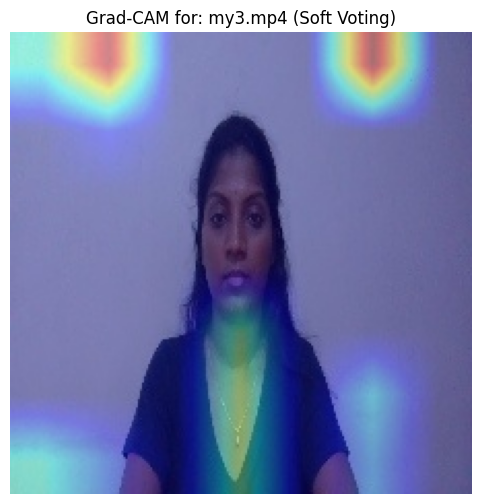

In [ ]:
external_soft_voting_gradcam_path = "Not generated"

try:
    # Get the mobilenet model (assuming it's a representative visual model)
    mobilenet_model = visual_models["mobilenet"]

    # Get the first frame from the external video's frame directory
    first_external_frame_sv = os.listdir(external_frame_dir_sv)[0]
    external_frame_path_sv = os.path.join(external_frame_dir_sv, first_external_frame_sv)

    # Define the save path for the external video's Grad-CAM image
    external_gradcam_save_path_sv = os.path.join(EXPLAIN_DIR, external_name_sv + "_soft_voting_gradcam.jpg")

    # Generate and save the Grad-CAM image
    external_soft_voting_gradcam_path = save_gradcam(
        external_frame_path_sv,
        mobilenet_model,
        external_gradcam_save_path_sv,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_soft_voting_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)

# Display the Grad-CAM image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if 'external_soft_voting_gradcam_path' in locals() and os.path.exists(external_soft_voting_gradcam_path):
    print("Displaying Grad-CAM for the external video:")
    img = mpimg.imread(external_soft_voting_gradcam_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide axes ticks
    plt.title(f'Grad-CAM for: {external_filename_sv} (Soft Voting)')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the external video (Soft Voting).")